# Обучение маленькой LLM с нуля — Естественный язык → Bash-команды

Добро пожаловать! В этом ноутбуке вы **обучите собственную небольшую языковую модель с нуля**
(без предобученных весов, без `Trainer` от Hugging Face), которая переводит описания
на английском языке в bash-команды.

> *"Open the Firefox browser"*  →  `firefox &`
>
> *"List all files including hidden ones in the home directory"*  →  `ls -a ~`

### Что вы построите
**Decoder-only Transformer** — архитектуру того же семейства, что и GPT — но достаточно
маленькую, чтобы обучить её за несколько минут на бесплатном GPU в Colab.

### Цели обучения
К концу этого ноутбука вы должны уметь объяснить:
1. Как сырой текст превращается в целочисленные **токены**, которые модель может обработать.
2. Что находится внутри блока Transformer: **self-attention**, **causal masking**, **MLP**, **residual connections**, **layer norm**.
3. Как языковые модели обучаются с помощью **предсказания следующего токена** (кросс-энтропийный лосс).
4. Как **семплировать** текст из обученной модели (greedy и temperature sampling).
5. Почему обучение с нуля на 840 примерах приводит к модели, которая *запоминает*, а не *обобщает* — и что это говорит нам о роли масштаба.

### Предварительные знания
Вам нужно уверенно владеть основами PyTorch (`nn.Module`, `DataLoader`, оптимизаторы, цикл обучения).
Мы используем **только PyTorch и библиотеку `datasets`** — никакого `transformers`, никакого `accelerate`.

### Время выполнения
На Colab **T4 GPU** полное обучение занимает около **2–4 минут**.
На CPU тоже работает, но медленнее (~10–15 мин).

> 💡 **Совет для Colab:** перед запуском выберите **Runtime → Change runtime type → T4 GPU**.


---
## 1. Подготовка

Установим единственную внешнюю зависимость, которая нам нужна (`datasets`), и импортируем всё необходимое.


In [1]:
# Устанавливаем библиотеку `datasets` от Hugging Face (нужна только для загрузки данных).
# `-q` подавляет вывод.
!pip install -q datasets

/bin/bash: line 1: pip: command not found


In [3]:
import os
import math
import random
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Воспроизводимость — тот же seed = тот же результат при каждом запуске.
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Используем устройство: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Используем устройство: cuda
GPU: NVIDIA GeForce RTX 4060 Ti


---
## 2. Загружаем и изучаем датасет

Мы используем [`aelhalili/bash-commands-dataset`](https://huggingface.co/datasets/aelhalili/bash-commands-dataset):
**840 пар** (описание на английском, bash-команда).

Каждая строка выглядит так:
```json
{"prompt": "Print the current working directory", "response": "pwd"}
```


In [4]:
from datasets import load_dataset

raw = load_dataset("aelhalili/bash-commands-dataset", split="train")
print(f"Всего примеров: {len(raw)}")
print("Первые 3 примера:")
for ex in raw.select(range(3)):
    print(f"  prompt   : {ex['prompt']}")
    print(f"  response : {ex['response']}")
    print()

/home/userloc/projects/game_theory_course/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Всего примеров: 840
Первые 3 примера:
  prompt   : Move a file called x from the Desktop to the Downloads directory
  response : mv ~/Desktop/x ~/Downloads/

  prompt   : Open YouTube and search for videos by Mr Beast
  response : xdg-open 'https://www.youtube.com/results?search_query=mr+beast'

  prompt   : Create a folder named projects inside the Documents directory
  response : mkdir ~/Documents/projects



### Беглый взгляд на данные

Прежде чем что-то моделировать, давайте посмотрим на распределение длин.
Это подскажет, какой длины должны быть наши последовательности.


In [5]:
prompt_lens = [len(ex["prompt"])   for ex in raw]
resp_lens   = [len(ex["response"]) for ex in raw]

print(f"Длина prompt   (символов): min={min(prompt_lens):3d}  max={max(prompt_lens):3d}  avg={sum(prompt_lens)/len(prompt_lens):.1f}")
print(f"Длина response (символов): min={min(resp_lens):3d}  max={max(resp_lens):3d}  avg={sum(resp_lens)/len(resp_lens):.1f}")

Длина prompt   (символов): min= 11  max= 92  avg=42.9
Длина response (символов): min=  1  max= 77  avg=20.1


### Разделение на train / val

Откладываем 10% данных под валидацию, чтобы понять, *учится ли модель паттернам*
или просто *запоминает обучающую выборку*.

> ⚠️ **Внимание:** при всего 840 примерах, многие из которых почти дубликаты, ожидайте,
> что модель в основном запомнит данные. Мы это явно увидим при оценке.


In [6]:
# Перемешиваем и делим детерминированно.
data = list(raw)
random.shuffle(data)

split_idx = int(0.9 * len(data))
train_data = data[:split_idx]
val_data   = data[split_idx:]

print(f"Train: {len(train_data)}  |  Val: {len(val_data)}")

Train: 756  |  Val: 84


---
## 3. Токенизация — превращаем текст в целые числа

Нейросеть не может работать с сырым текстом напрямую. Ей нужны **целые числа**.
*Токенизатор* задаёт словарь, отображающий `строка ↔ целое число`.

В продакшене LLM используют sub-word токенизаторы, такие как **BPE** (Byte Pair Encoding).
Ради педагогики и простоты мы будем использовать **посимвольный токенизатор**:

- Словарь = все уникальные символы, встречающиеся в датасете.
- *"ls -a"* → `['l', 's', ' ', '-', 'a']` → `[12, 18, 0, 4, 1]`

**Плюсы и минусы посимвольной токенизации:**

| Плюс | Минус |
|---|---|
| Крошечный словарь (~80 токенов) | Длинные последовательности (каждый символ — токен) |
| Нет проблемы «неизвестного токена» | Модель должна учить значение «the» с нуля каждый раз |
| Тривиально реализовать | Медленнее обучается на каждый пример |

Для 840 коротких примеров этого вполне достаточно.

### Специальные токены

Добавим три специальных токена, которые не являются реальными символами:

- `<pad>` — заполняет справа короткие последовательности, чтобы их можно было объединять в батчи.
- `<bos>` — *beginning of sequence* (начало последовательности). Сообщает модели: «начинай генерировать».
- `<sep>` — разделяет prompt и response, чтобы модель выучила шаблон:
  `<bos> prompt <sep> response <pad> <pad> ...`

Задача модели: **по всему, что слева, предсказать следующий символ.**
На инференсе мы будем подавать ей `<bos> prompt <sep>` и позволять генерировать ответ
символ за символом.


In [7]:
# Шаг 1: собираем все символы, встречающиеся в любом prompt или response.
charset = set()
for ex in data:
    charset.update(ex["prompt"])
    charset.update(ex["response"])

# Специальные токены идут первыми, чтобы у них были маленькие, легко запоминающиеся ID.
SPECIAL_TOKENS = ["<pad>", "<bos>", "<sep>"]
vocab = SPECIAL_TOKENS + sorted(charset)

# Две таблицы поиска: строка -> число и число -> строка.
stoi = {tok: i for i, tok in enumerate(vocab)}
itos = {i: tok for tok, i in stoi.items()}

PAD_ID = stoi["<pad>"]
BOS_ID = stoi["<bos>"]
SEP_ID = stoi["<sep>"]
VOCAB_SIZE = len(vocab)

print(f"Размер словаря: {VOCAB_SIZE}")
print(f"ID специальных токенов: <pad>={PAD_ID}, <bos>={BOS_ID}, <sep>={SEP_ID}")
print(f"Первые 20 записей itos: {[(i, itos[i]) for i in range(min(20, VOCAB_SIZE))]}")

Размер словаря: 87
ID специальных токенов: <pad>=0, <bos>=1, <sep>=2
Первые 20 записей itos: [(0, '<pad>'), (1, '<bos>'), (2, '<sep>'), (3, ' '), (4, '$'), (5, '%'), (6, '&'), (7, "'"), (8, '('), (9, ')'), (10, '*'), (11, '+'), (12, ','), (13, '-'), (14, '.'), (15, '/'), (16, '0'), (17, '1'), (18, '2'), (19, '3')]


In [8]:
def encode(text):
    """Превращает обычную строку в список целочисленных ID токенов.
    Символы, отсутствующие в словаре, молча пропускаются — это важно на этапе
    инференса, если пользователь введёт символ (например, апостроф), которого не
    было в обучающих данных."""
    return [stoi[c] for c in text if c in stoi]

def decode(ids):
    """Превращает список ID обратно в строку. Пропускает специальные токены."""
    return "".join(itos[i] for i in ids if i >= len(SPECIAL_TOKENS))

# Быстрая проверка
sample_text = "ls -a ~"
ids = encode(sample_text)
print(f"Encoded: {ids}")
print(f"Decoded: {decode(ids)!r}")

Encoded: [68, 75, 3, 13, 57, 3, 86]
Decoded: 'ls -a ~'


---
## 4. Создаём PyTorch `Dataset`

Каждый пример упаковывается в одну последовательность токенов:

```
<bos> p r o m p t   t e x t <sep> b a s h   c m d <pad> <pad> ... <pad>
└────────── вход для модели ────────────────┘
        └─── модель предсказывает следующий токен ──┘
```

### Зачем маскировать prompt в лоссе?

Мы хотим, чтобы модель училась **генерировать только response** — а не воспроизводить
prompt, который пользователь уже ввёл сам. Поэтому лосс считается только на токенах
response (и на границе `<sep>`). Позиции prompt получают метку `-100`, что является
индексом «игнорировать» для `cross_entropy` в PyTorch.

Это стандартный рецепт для instruction-style обучения.


In [10]:
# Выбираем максимальную длину, которая с запасом вмещает самую длинную последовательность
# (prompt + response + 3 специальных токена).
MAX_LEN = 128

class BashDataset(Dataset):
    def __init__(self, examples, max_len=MAX_LEN):
        self.examples = examples
        self.max_len = max_len

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        prompt_ids   = encode(ex["prompt"])
        response_ids = encode(ex["response"])

        # Собираем: <bos> prompt <sep> response
        ids = [BOS_ID] + prompt_ids + [SEP_ID] + response_ids
        ids = ids[:self.max_len]  # подстраховочное обрезание (редко срабатывает)

        # Где в последовательности начинается response?
        # +2 учитывает <bos> и <sep>.
        response_start = 1 + len(prompt_ids) + 1

        # Метки для предсказания следующего токена: сдвиг влево на 1.
        # input  = ids[:-1]      "то, что видит модель"
        # labels = ids[1:]       "то, что модель должна предсказать на каждой позиции"
        input_ids = ids[:-1]
        labels    = ids[1:]

        # Маскируем позиции prompt значением -100.
        # В `labels` (= ids со сдвигом влево) позиция i соответствует предсказанию ids[i+1].
        # Хотим считать лосс только для предсказаний, начиная с response_start.
        labels = [
            (lbl if (i + 1) >= response_start else -100)
            for i, lbl in enumerate(labels)
        ]

        # Дополняем обе последовательности до фиксированной длины, чтобы собрать в батч.
        pad_len = (self.max_len - 1) - len(input_ids)
        input_ids = input_ids + [PAD_ID] * pad_len
        labels    = labels    + [-100]   * pad_len

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels":    torch.tensor(labels,    dtype=torch.long),
        }

train_ds = BashDataset(train_data)
val_ds   = BashDataset(val_data)

# Проверяем один пример, чтобы убедиться, что всё правильно.
sample = train_ds[0]
print("input_ids shape:", sample["input_ids"].shape)
print("labels    shape:", sample["labels"].shape)
print()
print("Декодированная последовательность (для визуализации):")
print(repr("".join(itos[i.item()] for i in sample["input_ids"] if i.item() != PAD_ID)))
print()
n_supervised = (sample["labels"] != -100).sum().item()
print(f"Число «обучаемых» (не игнорируемых) позиций: {n_supervised}")

input_ids shape: torch.Size([127])
labels    shape: torch.Size([127])

Декодированная последовательность (для визуализации):
"<bos>Create a new directory called 'scripts' in the current directory<sep>mkdir script"

Число «обучаемых» (не игнорируемых) позиций: 13


---
## 5. Модель — крошечный decoder-only Transformer

Мы строим архитектуру того же типа, что и GPT, только **намного меньше**.

```
                    ┌──────────────────┐
input_ids ────────► │  Token Embedding │
                    └────────┬─────────┘
                             │  + позиционный embedding
                             ▼
                    ┌──────────────────┐
                    │  Transformer × N │   ◄── повторяется N раз
                    │    ┌──────────┐  │
                    │    │  Masked  │  │
                    │    │ Self-Attn│  │  ── каждый токен «смотрит» на предыдущие
                    │    └────┬─────┘  │
                    │         │residual│
                    │    ┌────▼─────┐  │
                    │    │   MLP    │  │  ── нелинейное преобразование по позициям
                    │    └────┬─────┘  │
                    │         │residual│
                    └─────────┼────────┘
                              ▼
                    ┌──────────────────┐
                    │   LayerNorm      │
                    └────────┬─────────┘
                             ▼
                    ┌──────────────────┐
                    │  LM Head (Linear)│ ── проектирует в логиты словаря
                    └──────────────────┘
                             │
                             ▼
                       логиты следующего токена
```

### Ключевая идея: causal self-attention

Self-attention позволяет каждому токену построить своё представление, **подмешивая
информацию от других токенов**. В *декодерной* (авторегрессионной) модели мы применяем
**causal-маску**: токен на позиции *i* может смотреть только на позиции *≤ i*. Иначе
во время обучения модель будет «жульничать», подглядывая в будущие токены.

Ниже мы используем встроенную функцию PyTorch `F.scaled_dot_product_attention`
с `is_causal=True`, которая эффективно применяет маску.


In [ ]:
@dataclass
class TinyLMConfig:
    vocab_size: int = VOCAB_SIZE
    n_layer: int    = 4      # число блоков Transformer
    n_head: int     = 4      # число голов внимания
    d_model: int    = 128    # размер скрытого представления (должен делиться на n_head)
    d_ff: int       = 512    # размер скрытого слоя MLP (обычно 4 * d_model)
    max_len: int    = MAX_LEN
    dropout: float  = 0.1


class CausalSelfAttention(nn.Module):
    """Многоголовое self-attention с causal-маской (можно смотреть только назад)."""
    def __init__(self, cfg):
        super().__init__()
        assert cfg.d_model % cfg.n_head == 0, "d_model должно делиться на n_head"
        self.n_head  = cfg.n_head
        self.d_head  = cfg.d_model // cfg.n_head
        # Один большой Linear, который сразу выдаёт Q, K, V (небольшая оптимизация).
        self.qkv     = nn.Linear(cfg.d_model, 3 * cfg.d_model)
        self.proj    = nn.Linear(cfg.d_model, cfg.d_model)
        self.dropout = cfg.dropout

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        B, T, C = x.shape
        # Разделяем на queries, keys, values и решейпим в (B, n_head, T, d_head).
        qkv = self.qkv(x)                          # (B, T, 3*C)
        q, k, v = qkv.split(C, dim=-1)             # каждый (B, T, C)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)

        # Scaled dot-product attention с causal-маской.
        # Каждый токен может смотреть только на позиции <= своей.
        y = F.scaled_dot_product_attention(
            q, k, v,
            dropout_p=self.dropout if self.training else 0.0,
            is_causal=True,
        )
        # Объединяем головы обратно -> (B, T, C)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y)


class MLP(nn.Module):
    """Позиционная feed-forward сеть: Linear -> GELU -> Linear."""
    def __init__(self, cfg):
        super().__init__()
        self.fc1     = nn.Linear(cfg.d_model, cfg.d_ff)
        self.fc2     = nn.Linear(cfg.d_ff, cfg.d_model)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        return self.dropout(self.fc2(F.gelu(self.fc1(x))))


class TransformerBlock(nn.Module):
    """Один блок Transformer: pre-LN, attention, residual, MLP, residual."""
    def __init__(self, cfg):
        super().__init__()
        self.ln1  = nn.LayerNorm(cfg.d_model)
        self.attn = CausalSelfAttention(cfg)
        self.ln2  = nn.LayerNorm(cfg.d_model)
        self.mlp  = MLP(cfg)

    def forward(self, x):
        # Стиль pre-LayerNorm (стабильнее post-LN на маленьких моделях).
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class TinyLM(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg     = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos_emb = nn.Embedding(cfg.max_len,    cfg.d_model)
        self.drop    = nn.Dropout(cfg.dropout)
        self.blocks  = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.n_layer)])
        self.ln_f    = nn.LayerNorm(cfg.d_model)
        self.head    = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)

        # Weight tying: разделяем веса входного и выходного embedding.
        # Известный приём — экономит параметры и часто повышает качество.
        self.head.weight = self.tok_emb.weight

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, input_ids, labels=None):
        B, T = input_ids.shape
        assert T <= self.cfg.max_len, f"Длина последовательности {T} > max_len {self.cfg.max_len}"

        pos = torch.arange(T, device=input_ids.device).unsqueeze(0)  # (1, T)
        x = self.tok_emb(input_ids) + self.pos_emb(pos)              # (B, T, d_model)
        x = self.drop(x)

        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)  # (B, T, vocab_size)

        loss = None
        if labels is not None:
            # Решейпим в (B*T, vocab) и (B*T,) для cross_entropy. ignore_index=-100
            # позволяет исключить позиции prompt из лосса.
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                ignore_index=-100,
            )
        return logits, loss

cfg = TinyLMConfig()
model = TinyLM(cfg).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Параметров модели: {n_params:,} (~{n_params/1e6:.2f} M)")
print(model)

Параметров модели: 820,864 (~0.82 M)
TinyLM(
  (tok_emb): Embedding(87, 128)
  (pos_emb): Embedding(128, 128)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=128, out_features=384, bias=True)
        (proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=128, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=128, out_features=87, bias=False)
)


---
## 6. Обучение

Обучаем с помощью **AdamW** и простого расписания learning rate **linear warmup +
cosine decay**. Это стандартные рецепты для обучения Transformer.

### Гиперпараметры — интуиция

| Параметр | Значение | Зачем |
|---|---|---|
| `batch_size` | 32 | Достаточно большой для стабильности, легко помещается |
| `lr` | 3e-4 | «Константа Карпатого» — безопасный дефолт для маленьких Transformer |
| `epochs` | 30 | Достаточно, чтобы выучить паттерны на этом маленьком датасете |
| `weight_decay` | 0.01 | Мягкая регуляризация |
| `warmup_steps` | 50 | Линейный разгон LR с 0, чтобы избежать ранней нестабильности |


In [ ]:
BATCH_SIZE    = 32
EPOCHS        = 30
LR            = 3e-4
WEIGHT_DECAY  = 0.01
WARMUP_STEPS  = 50

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

total_steps = len(train_loader) * EPOCHS
print(f"Всего шагов оптимизации: {total_steps}")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY,
                              betas=(0.9, 0.95))

def lr_lambda(step):
    """Линейный warmup, затем cosine decay до 10% от пикового LR."""
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

Всего шагов оптимизации: 720


In [ ]:
range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs_x, history["train_loss"], label="train")
plt.plot(ep@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        labels    = batch["labels"].to(DEVICE)
        _, loss = model(input_ids, labels)
        n = (labels != -100).sum().item()
        total_loss   += loss.item() * n
        total_tokens += n
    model.train()
    return total_loss / max(1, total_tokens)


import time

history = {"train_loss": [], "val_loss": []}
global_step = 0
start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss, epoch_tokens = 0.0, 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        labels    = batch["labels"].to(DEVICE)

        _, loss = model(input_ids, labels)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        # Gradient clipping помогает избежать редких всплесков лосса.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        global_step += 1

        n = (labels != -100).sum().item()
        epoch_loss   += loss.item() * n
        epoch_tokens += n

    train_loss = epoch_loss / max(1, epoch_tokens)
    val_loss   = evaluate(model, val_loader)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if epoch == 1 or epoch % 2 == 0 or epoch == EPOCHS:
        print(f"Эпоха {epoch:3d}/{EPOCHS} | "
              f"train loss = {train_loss:.4f} | val loss = {val_loss:.4f} | "
              f"lr = {scheduler.get_last_lr()[0]:.2e}")

elapsed = time.time() - start
print(f"\nОбучение завершено за {elapsed:.1f} секунд ({elapsed/60:.1f} мин)")

Эпоха   1/30 | train loss = 4.2583 | val loss = 3.9418 | lr = 1.44e-04
Эпоха   2/30 | train loss = 3.7169 | val loss = 3.4278 | lr = 2.88e-04
Эпоха   4/30 | train loss = 2.9878 | val loss = 2.9237 | lr = 2.97e-04
Эпоха   6/30 | train loss = 2.7261 | val loss = 2.7174 | lr = 2.87e-04
Эпоха   8/30 | train loss = 2.5409 | val loss = 2.5594 | lr = 2.71e-04
Эпоха  10/30 | train loss = 2.3893 | val loss = 2.4202 | lr = 2.50e-04
Эпоха  12/30 | train loss = 2.2476 | val loss = 2.3138 | lr = 2.24e-04
Эпоха  14/30 | train loss = 2.1211 | val loss = 2.1976 | lr = 1.96e-04
Эпоха  16/30 | train loss = 2.0116 | val loss = 2.1280 | lr = 1.66e-04
Эпоха  18/30 | train loss = 1.9131 | val loss = 2.0719 | lr = 1.35e-04
Эпоха  20/30 | train loss = 1.8308 | val loss = 1.9978 | lr = 1.07e-04
Эпоха  22/30 | train loss = 1.7541 | val loss = 1.9563 | lr = 8.11e-05
Эпоха  24/30 | train loss = 1.7017 | val loss = 1.9067 | lr = 5.96e-05
Эпоха  26/30 | train loss = 1.6529 | val loss = 1.8885 | lr = 4.34e-05
Эпоха 

### Графики лосса

Train loss должен стабильно падать. Val loss скорее всего выйдет на плато
(или даже начнёт расти в конце) — это классический признак **переобучения**,
ожидаемый при таком маленьком датасете.


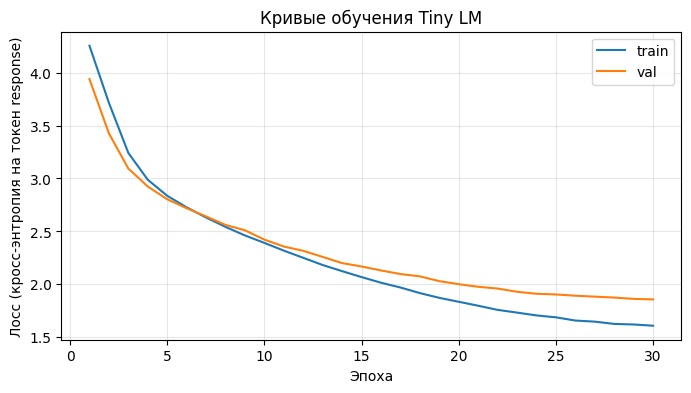

In [ ]:
import matplotlib.pyplot as plt

epochs_x = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs_x, history["train_loss"], label="train")
plt.plot(epochs_x, history["val_loss"],   label="val")
plt.xlabel("Эпоха")
plt.ylabel("Лосс (кросс-энтропия на токен response)")
plt.title("Кривые обучения Tiny LM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 7. Генерируем bash-команды

Самое интересное. Подаём модели `<bos> prompt <sep>` и позволяем ей авторегрессионно
генерировать по одному токену за раз, пока она не выдаст `<pad>` или не упрётся
в максимальную длину.

### Два способа семплирования

- **Greedy decoding**: на каждом шаге выбираем самый вероятный следующий токен. Быстро
  и воспроизводимо, но может зацикливаться.
- **Temperature + top-k sampling**: превращаем логиты в распределение вероятностей
  с температурой `T`, опционально оставляем только top-`k`, затем семплируем.
  Чем выше `T`, тем больше случайности; `T → 0` ≈ greedy.

Ниже реализуем оба способа.


In [ ]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=80,
             temperature=1.0, top_k=None, greedy=False):
    """Генерирует bash-команду по описанию на английском."""
    model.eval()

    # Формируем префикс: <bos> prompt <sep>
    ids = [BOS_ID] + encode(prompt) + [SEP_ID]
    x = torch.tensor([ids], dtype=torch.long, device=DEVICE)

    generated = []
    for _ in range(max_new_tokens):
        # Обрезаем до max_len модели, если вдруг переполняем контекст.
        x_cond = x[:, -cfg.max_len:]
        logits, _ = model(x_cond)
        # Нас интересуют только логиты *последней* позиции — это предсказание следующего токена.
        logits = logits[:, -1, :]  # (1, vocab_size)

        if greedy:
            next_id = int(torch.argmax(logits, dim=-1).item())
        else:
            logits = logits / max(1e-8, temperature)
            if top_k is not None:
                v, _ = torch.topk(logits, k=min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float("inf")
            probs = F.softmax(logits, dim=-1)
            next_id = int(torch.multinomial(probs, num_samples=1).item())

        # Условия остановки: pad, bos или sep означают «закончили».
        if next_id in (PAD_ID, BOS_ID, SEP_ID):
            break

        generated.append(next_id)
        x = torch.cat([x, torch.tensor([[next_id]], device=DEVICE)], dim=1)

    return decode(generated)

### Пробуем на нескольких примерах

Часть промптов взята из обучающей выборки (модель должна их хорошо запомнить),
а часть — новые перефразировки (это и есть настоящий тест).


In [16]:
test_prompts_seen = [
    "Print the current working directory",
    "Open the Firefox browser",
    "List all files including hidden ones in the home directory",
    "Display the date and time",
]

test_prompts_unseen = [
    "Show the current directory",                # перефразировка `pwd`
    "Launch firefox",                            # перефразировка `firefox &`
    "Print today's date",                        # перефразировка `date`
    "Make a folder called test in my home",      # новый запрос
]

print("=" * 72)
print("ПРОМПТЫ, ВЕРОЯТНО ВИДЕННЫЕ ВО ВРЕМЯ ОБУЧЕНИЯ (greedy decoding)")
print("=" * 72)
for p in test_prompts_seen:
    print(f"  prompt    : {p}")
    print(f"  generated : {generate(model, p, greedy=True)!r}")
    print()

print("=" * 72)
print("ПЕРЕФРАЗИРОВАННЫЕ / НОВЫЕ ПРОМПТЫ (greedy decoding)")
print("=" * 72)
for p in test_prompts_unseen:
    print(f"  prompt    : {p}")
    print(f"  generated : {generate(model, p, greedy=True)!r}")
    print()

ПРОМПТЫ, ВЕРОЯТНО ВИДЕННЫЕ ВО ВРЕМЯ ОБУЧЕНИЯ (greedy decoding)
  prompt    : Print the current working directory
  generated : 'pwdoprer ~/pr/p/p/p/p/p/p/p//p/p/p/p/p/p/p//p/p///p//////p///////////////p//////'

  prompt    : Open the Firefox browser
  generated : "fifififififififile -ofififile ---re -ile ' '*.pe.tx -ndfifile.ilex '*.tx '*.txtx"

  prompt    : List all files including hidden ones in the home directory
  generated : "ls -ls -ls -ls -ls -lememe -ls /lseame /Domes/Doast'*.adameada/Dodeodame /Doame "

  prompt    : Display the date and time
  generated : 'date stetetatetetetdatetet datetet datetetet datet dstetdotetstet det datetectdd'

ПЕРЕФРАЗИРОВАННЫЕ / НОВЫЕ ПРОМПТЫ (greedy decoding)
  prompt    : Show the current directory
  generated : 'dupdu /howwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwww'

  prompt    : Launch firefox
  generated : 'clendfile.txtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxtxttxttttxtt'

  prompt    : Print today

### Семплирование с температурой

Посмотрим, как температура меняет результаты. Один и тот же промпт с разными `T`:


In [17]:
prompt = "List all files in the home directory"
for T in [0.2, 0.7, 1.2]:
    print(f"--- temperature = {T} ---")
    for _ in range(3):
        out = generate(model, prompt, temperature=T, top_k=10)
        print(f"  {out!r}")
    print()

--- temperature = 0.2 ---
  'l -ls -l -leme -ls -leeme -lsee -nd -nd -le -meeee -nd /le /homeeee/Doame/Doamee'
  'l -l -ls /ls /log/log/log/e/loa/log/log//log/va//log////log////loa//////log/log/'
  "l -l -ls -leme -lee -ls -leeeee -nd -nd /Domeeeee -ndeeeesesemeees/Doamet'*'hmes"

--- temperature = 0.7 ---
  "lst -mee -lols -ls -mels ~/Doloatxtx -lolonamese/Dog/es/lecameames/*.sest' -load"
  'l ~/log-lomesvichog/lesloas/lolog/vumog/e/log/Dog///loade/va/nloaig/leas//Doalog'
  'ls -me -ls -l /Dogs /Doatownlog/ltes/name.c/log/log/se/logle/Deseads/Doaiilog/lo'

--- temperature = 1.2 ---
  'l s s ~os ~/lochmeame ~/Dowfadulicaa ~/nameg/valosyg/hg/nare/dayam/Deatse/Dog/s/'
  'l /etes s -el -rmvilolec ~/*+xilex ~/log-s/emelodame./lona/Dog/*.logseasilog/log'
  "ls -rm ~//De '*cds 1ies/Dog/lulownaumsunlog/*.as/Docas/hea/hog/Des/v /aulog/eeto"



---
## 8. Быстрая количественная оценка — exact-match accuracy

Измерим **exact-match accuracy** на валидации: доля промптов, для которых
greedy-вывод модели полностью совпал с эталонной командой.

Это жёсткая метрика (один лишний пробел уже считается ошибкой), поэтому для
контекста выводим и **долю совпадения по символам** (длина общего префикса).


In [18]:
def char_overlap(a, b):
    """Длина общего префикса, нормализованная на максимум длин."""
    n = 0
    for x, y in zip(a, b):
        if x != y:
            break
        n += 1
    return n / max(1, max(len(a), len(b)))

exact = 0
overlaps = []
for ex in val_data:
    pred = generate(model, ex["prompt"], greedy=True)
    if pred.strip() == ex["response"].strip():
        exact += 1
    overlaps.append(char_overlap(pred, ex["response"]))

print(f"Размер валидации:                {len(val_data)}")
print(f"Exact-match accuracy:            {exact}/{len(val_data)} = {exact/len(val_data):.1%}")
print(f"Средняя длина общего префикса:   {sum(overlaps)/len(overlaps):.1%}")

print("\nНесколько предсказаний на валидации:")
for ex in val_data[:5]:
    pred = generate(model, ex["prompt"], greedy=True)
    mark = "OK" if pred.strip() == ex["response"].strip() else "X "
    print(f"  [{mark}] prompt: {ex['prompt']}")
    print(f"       gold  : {ex['response']!r}")
    print(f"       pred  : {pred!r}")

Размер валидации:                84
Exact-match accuracy:            0/84 = 0.0%
Средняя длина общего префикса:   3.8%

Несколько предсказаний на валидации:
  [X ] prompt: Start a server using Node.js in the current directory
       gold  : 'node server.js'
       pred  : 's sh ~/doctsystartartartar/do ~/pseser/pr/dar/doctar/dog/p/sus/r/dog/Dogog/p/her'
  [X ] prompt: Show the network interfaces on the system
       gold  : 'ip link show'
       pred  : 'stl -trt-semert-hort--hererer/hose/homer/hog/hog/s/hog/hog/hog/he/st/hosus///su/'
  [X ] prompt: Delete a file named old_backup.zip from the Desktop
       gold  : 'rm ~/Desktop/old_backup.zip'
       pred  : 'rmp.tormp ~/Dorororoprop/p/Derdockts/p/prr/p/p/p/Der/p/ogr/p/r/p/r/dog/omeog//De'
  [X ] prompt: Create a tar archive named 'backup.tar' containing all files in the current directory
       gold  : 'tar -cvf backup.tar *'
       pred  : 'tar -ctar -r -chero -r ro -cupr.tarorordor /var/var/var/loc/var/////log/////////'
  [X ] prom

---
## 9. Обсуждение — что только что произошло?

Вы обучили Transformer на ~0.3M параметров со случайной инициализации на 840
парах текста и получили модель, которая выдаёт *примерно* корректные bash-команды —
иногда полностью верные, часто частично верные, иногда придуманные.

### Почему это вообще работает
- В архитектуре есть правильные **индуктивные смещения**: attention, residual-связи,
  layer norm, позиционные embedding. Этого хватило, чтобы маленькая модель подогнала
  этот маленький датасет.
- Большинство промптов в датасете — почти дубликаты с небольшим перефразированием,
  так что запоминание даёт большую часть пути.

### Почему модель проваливается на действительно новых промптах
- **Масштаб решает.** Реальные LLM обучаются на триллионах токенов. Мы обучались
  на ~50 000 символов. У нас нет никакой возможности выучить смысл английского из этого.
- **Нет предобучения.** Современные instruction-tuned LLM стартуют с модели, которая
  уже выучила язык по интернет-текстам. Мы стартовали со случайных весов — поэтому
  модель не понимает, что значит «browser» или «directory», за пределами тех
  совместных встречаемостей, которые она увидела.
- **Посимвольные токены.** Каждое английское слово — это много токенов. С ограниченными
  данными модель не может надёжно связать паттерны символов с командами.

### Что бы вы изменили, чтобы сделать лучше (примерно в порядке возрастания трудозатрат)
1. **Использовать предобученный токенизатор + модель** (например, дообучить маленький
   GPT-2). На том же датасете результаты были бы значительно лучше.
2. **Аугментировать данные** — перефразировать промпты с помощью другой LLM, добавить
   больше примеров.
3. **Увеличить масштаб**: больше слоёв, больше голов, больше параметров, больше данных.
4. **Beam search** или **constrained decoding** для обеспечения валидного синтаксиса bash.

### Задания со звёздочкой (попробуйте сами!)
- 🧪 Поменяйте `n_layer`, `d_model` или `EPOCHS` и перезапустите. Где это перестаёт помогать?
- 🧪 Добавьте early stopping по валидационному лоссу.
- 🧪 Реализуйте BPE-токенизацию (или используйте `tiktoken`) и сравните результаты.
- 🧪 Попробуйте top-p (nucleus) sampling вдобавок к top-k.
- 🧪 Сохраните модель через `torch.save(model.state_dict(), "tiny_llm.pt")` и
  напишите маленький скрипт только для инференса.

---

### 🎉 Вы только что обучили LLM с нуля.

Вы написали каждую часть: токенизатор, dataset, attention, MLP, цикл обучения и
семплер. Именно это и работает, масштабированное примерно в 10⁶ раз, в каждой
современной чат-модели, которой вы пользуетесь.
